# SetUp

In [8]:
!pip install -q langgraph langchain openai langsmith graphviz
!pip install -q langchain_community --upgrade

import os
from langchain.chat_models import ChatOpenAI
from langgraph.graph import StateGraph, END
from langsmith import traceable
from typing import Dict, Any
import graphviz

In [9]:
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "memory-agent-langgraph"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_API_KEY"] = ""  # Replace this securely
os.environ["OPENAI_API_KEY"] = "sk---"

# Memory-Aware Chat Agent

In [10]:
# ---
# Memory-Aware Chat Agent
@traceable(name="ConversationalAgent")
def memory_chat_agent(state):
    user_input = state["input"]
    chat_history = state.get("memory", [])
    llm = ChatOpenAI(temperature=0)

    prompt = "You are a helpful assistant in a long conversation. Use memory context if relevant."
    messages = [{"role": "system", "content": prompt}] + chat_history + [{"role": "user", "content": user_input}]
    response = llm.invoke(messages)

    updated_memory = chat_history + [{"role": "user", "content": user_input}, {"role": "assistant", "content": response.content}]
    return {"response": response.content, "memory": updated_memory}

# Build LangGraph with Memory

In [11]:
# ---
# Build LangGraph with Memory
workflow = StateGraph(state_schema=Dict[str, Any])
workflow.add_node("chat", memory_chat_agent)
workflow.set_entry_point("chat")
workflow.set_finish_point("chat")

graph = workflow.compile()

# Visualize the Memory Agent Graph

In [12]:
# ---
# Visualize the Memory Agent Graph
viz = graphviz.Digraph()
viz.attr(rankdir="LR")
viz.node("chat", shape="box")
viz.node("END", shape="oval")
viz.edge("chat", "END")
viz.render("memory_agent_graph", format="png", cleanup=False, view=True)

'memory_agent_graph.png'

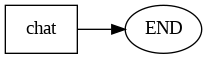

In [13]:
viz.render("react_langgraph_simple", format="png", cleanup=False, view=True)

from IPython.display import Image, display
display(Image(filename="memory_agent_graph.png"))

# Simulate Conversation

In [14]:
# ---
# Simulate Conversation
memory_state = {"memory": []}

for user_query in [
    "Hi, who won the World Cup in 2018?",
    "Remind me what we just talked about.",
    "Now give me a fact about the winning country."
]:
    print(f"\nUser: {user_query}")
    memory_state["input"] = user_query
    memory_state = graph.invoke(memory_state)
    print(" Agent:", memory_state["response"])


User: Hi, who won the World Cup in 2018?
 Agent: The 2018 FIFA World Cup was won by the French national team. They defeated Croatia 4-2 in the final to claim their second World Cup title.

User: Remind me what we just talked about.
 Agent: We just discussed the winner of the 2018 FIFA World Cup, which was the French national team.

User: Now give me a fact about the winning country.
 Agent: France is known for its rich history, diverse culture, and delicious cuisine. The country is also famous for iconic landmarks such as the Eiffel Tower, Louvre Museum, and Notre-Dame Cathedral.


In [15]:
# ---
# Simulate Conversation
memory_state = {"memory": []}

for user_query in [
    "Hi, whats the latest interesting news you know and can share it with me?",
    "Remind me what we just talked about.",
    "Now give me a random fact ."
]:
    print(f"\nUser: {user_query}")
    memory_state["input"] = user_query
    memory_state = graph.invoke(memory_state)
    print(" Agent:", memory_state["response"])


User: Hi, whats the latest interesting news you know and can share it with me?
 Agent: Hello! I don't have real-time capabilities to provide the latest news updates. However, I can suggest checking reputable news websites or apps for the most current and interesting news stories. If you have any specific topics in mind that you're interested in, feel free to let me know, and I can provide information or insights on those subjects.

User: Remind me what we just talked about.
 Agent: We just discussed the fact that I don't have real-time capabilities to provide the latest news updates, but I can suggest checking reputable news websites or apps for the most current and interesting news stories. If you have any specific topics in mind that you're interested in, feel free to let me know, and I can provide information or insights on those subjects.

User: Now give me a random fact .
 Agent: Sure! Here's a random fact for you: Did you know that honey never spoils? Archaeologists have found p

In [16]:
# ---
# Try more memory-sensitive prompts
print("""
Try adding:
- What's my name? (after telling it)
- What topics have we discussed?
""")


Try adding:
- What's my name? (after telling it)
- What topics have we discussed?

